## Redes clasificación 2

In [1]:
#importar las librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import seaborn as sns
import plotly.graph_objects as go
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer, Binarizer, RobustScaler, label_binarize
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, PowerTransformer
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.tree import DecisionTreeClassifier, export_text, DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score

In [7]:
seed=12345 #fijamos la semilla de aleatorización para que sea la misma en todo el proceso
#Reemplaza con la ruta correcta y nombre de tu archivo
file_path = 'C:/Users/user/OneDrive - Universidad Complutense de Madrid (UCM)/Documentos/Titulo Propio/Machine Learning/Redes Neuronales/Python/Datasets/SAheart.csv' 
#convertir a data frame el archivo
df = pd.read_csv(file_path)
#La variable de interés es chd, binaria Si/No
#analizamos la frecuencia de cada clase
print(f'\n Instancias: {df.shape[0]}; Variables: {df.shape[1]}')
print(f'\nLa frecuencia de cada clase es: \n{df.chd.value_counts()}')


 Instancias: 462; Variables: 10

La frecuencia de cada clase es: 
chd
No    302
Si    160
Name: count, dtype: int64


In [9]:
# Si se quiere categorizar la variable de respuesta (útil cuando tiene 1/0)
#df['chd'] = df['chd'].apply(lambda x: 'Yes' if x == 1 else 'No')
#en nuestro caso, cambiamos Si por Yes
df['chd'] = df['chd'].apply(lambda x: 'Yes' if x == 'Si' else 'No')

In [11]:
# hay valores perdidos?
df.isna().sum()

sbp          0
tobacco      0
ldl          0
adiposity    0
famhist      0
typea        0
obesity      0
alcohol      0
age          0
chd          0
dtype: int64

Preparamos la base de datos para la aplicación de redes neuronales:

    - Estandarizar/normalizar variables continuas
    - Convertir a dummies las variables categóricas
    - Evitar missing

In [13]:
# organiza las variables según su rol y naturaleza
# determina variable objetivo
target = "chd"
#hacer una lista con las variables input numericas
num_cols = ['sbp', 'tobacco', 'ldl', 'adiposity', 'typea', 'obesity', 'alcohol', 'age']
#hacer una lista con las variables input categóricas
cat_cols = ['famhist']

In [15]:
#Convertir a dummies las categóricas
#solo hay una variable categórica, transformación fácil
df[['famhist']] = pd.get_dummies(df[['famhist']],drop_first=True)
#otra opción
cat_cols = ColumnTransformer(transformers=[ ('ohe', OneHotEncoder(drop='first'), cat_cols)], 
                                                  remainder='passthrough')


## `GridSearchCV`
`GridSearchCV` es una función de la biblioteca scikit-learn que se utiliza para realizar una búsqueda exhaustiva sobre un conjunto especificado de hiperparámetros para un modelo de aprendizaje automático. La idea es probar todas las combinaciones posibles de hiperparámetros especificados en una cuadrícula y seleccionar la combinación que ofrece el mejor rendimiento según una métrica determinada.

1. **Definición del Modelo:** Se selecciona un modelo junto con un conjunto de hiperparámetros para optimizar. Los hiperparámetros son configuraciones ajustables que afectan el rendimiento y el comportamiento del modelo.

2. **Definición de la Cuadrícula/Rejilla de Parámetros:** Se especifican los valores posibles para cada hiperparámetro que se desea ajustar. `GridSearchCV` probará todas las combinaciones posibles de estos valores.

3. **División de Datos:** Los datos se dividen en conjuntos de entrenamiento y prueba. Durante la búsqueda de la cuadrícula, el modelo se ajusta a los datos de entrenamiento y se evalúa en el conjunto de prueba.

4. **Evaluación del Rendimiento:** Se elige una métrica de evaluación, como precisión, exactitud, F1-score, etc. (¡depende del problema considerado!). Esta métrica se utilizará para evaluar el rendimiento del modelo en cada combinación de hiperparámetros.

5. **Búsqueda Exhaustiva:** `GridSearchCV` realiza una búsqueda exhaustiva probando todas las combinaciones posibles de hiperparámetros en la cuadrícula. Ajusta el modelo con cada combinación y evalúa su rendimiento utilizando la métrica especificada.

6. **Selección del Mejor Modelo:** Una vez que se han probado todas las combinaciones, `GridSearchCV` selecciona la combinación de hiperparámetros que proporcionó el mejor rendimiento según la métrica elegida.

`GridSearchCV` automatiza el proceso de ajuste de hiperparámetros al probar sistemáticamente diferentes combinaciones, lo que facilita la identificación de la configuración óptima para un modelo en particular.

`refit` es un parámetro que determina si ajustar o no el estimador final utilizando los mejores hiperparámetros encontrados durante la búsqueda en la cuadrícula.

Cuando refit está establecido en True (que es el valor predeterminado), después de completar la búsqueda en la cuadrícula, GridSearchCV ajustará automáticamente el estimador utilizando los mejores hiperparámetros encontrados en todo el conjunto de datos de entrenamiento.

**IMPORTANTE** el valor añadido de un analista es encontrar el equilibrio entre la calidad del modelo y su complejidad, las necesidades y requerimientos de cada problema, el mantenimiento y cuidado que se le podrá prestar al modelo, etc. Limitarse al "mejor modelo" propocionado por GridSearchCV sería nuestro final como analistas. Es IMPRESCINDIBLE ir más allá de la parametrización que optimiza numéricamente la medida de bondad escogida.

### Sobre la transformación de variables
En este ejemplo tenemos variables categóricas y continuas en X, por lo que tenemos que aplicar `ColumnTransformer` para aplicarle a cada tipo de variable la transformación que le corresponda: en general, estandarizar las continuas, convertir a dummies con OHE las categóricas

In [28]:
# Tuneo y evaluación predictiva del modelo para variable dependiente continua
# El grupo de variables predictoras se define y se fija
X = df[['famhist','tobacco','alcohol']] #en X las variables ya están normalizadas y con dummies
y = df['chd']

# 1. División de dato
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

## 2. Transformación de variables
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
transformador = ColumnTransformer([('OHE',OneHotEncoder(drop='first'),['famhist']), 
                                   ('MinMax',MinMaxScaler(),['tobacco','alcohol'])])
X_train=transformador.fit_transform(X_train)
X_test=transformador.transform(X_test)

#3. Definio el modelo base
red = MLPClassifier(random_state=1234)
#definimos los parámetros que queremos tunear
params = {
    'max_iter': [600], #cantidad de iteraciones que se le permiten al algoritmo de optimizacion
    'hidden_layer_sizes': [5,7,9],#redes con una sola capa oculta, con un tamaño distinto en cada arquitectura
    'activation': ['tanh','relu'], #función de activación usada
    'alpha': [0.001,0.0001] #regularización L2, valor alto puede resultar en un modelo más sesgado pero con menor varianza. 
    #valor más bajo permite que el modelo se ajuste más a los datos de tr, aunque con un mayor riesgo de sobreajuste
}
scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
# cv = crossvalidation con n folds con todas las combinaciones de parámetros
# GridSearchCV utiliza la función .predict como método subyacente, por lo tanto, clasifica
#en la clase con probabilidad más alta, lo que es equivalente a usar 0.5 como threshold
grid_search = GridSearchCV(estimator=red, 
                           param_grid=params, 
                           cv=4, scoring = scoring_metrics, refit='accuracy')

#ajusta en entrenamiento con todas las combinaciones
grid_search.fit(X_train, y_train)

GridSearchCV(cv=4, estimator=MLPClassifier(random_state=1234),
             param_grid={'activation': ['tanh', 'relu'],
                         'alpha': [0.001, 0.0001],
                         'hidden_layer_sizes': [5, 7, 9], 'max_iter': [600]},
             refit='accuracy',
             scoring=['accuracy', 'precision_macro', 'recall_macro',
                      'f1_macro'])

`best_estimator_` es el modelo que obtuvo la **mejor puntuación media de validación** durante la búsqueda de hiperparámetros (por ejemplo, con `GridSearchCV` o `RandomizedSearchCV`). Es decir, se elige el conjunto de hiperparámetros que **maximiza la métrica usada en la validación cruzada**.

**Importante:** no es conveniente limitarse solo a eso; el resultado debe evaluarse después en un **conjunto de test independiente** para comprobar la capacidad real de generalización. Además, no tiene capacidad para discernir si compensa la ganancia en calidad con la complejidad del modelo, ni para hablar de estabilidad o robustez


In [29]:
# Obtener resultados del grid search
results = pd.DataFrame(grid_search.cv_results_)
# Mostrar resultados
print("Resultados de Grid Search:")
print(results[['params', 'mean_test_accuracy', 'mean_test_precision_macro', 'mean_test_recall_macro', 'mean_test_f1_macro']])
#print(results) #para ver todos los atributos obtenidos y entender cómo usarlos

# Obtener el mejor modelo (en cuanto a optimización del criterio)
best_model = grid_search.best_estimator_
print(grid_search.best_estimator_)

Resultados de Grid Search:
                                               params  mean_test_accuracy  \
0   {'activation': 'tanh', 'alpha': 0.001, 'hidden...            0.712804   
1   {'activation': 'tanh', 'alpha': 0.001, 'hidden...            0.720956   
2   {'activation': 'tanh', 'alpha': 0.001, 'hidden...            0.726391   
3   {'activation': 'tanh', 'alpha': 0.0001, 'hidde...            0.712804   
4   {'activation': 'tanh', 'alpha': 0.0001, 'hidde...            0.720956   
5   {'activation': 'tanh', 'alpha': 0.0001, 'hidde...            0.726391   
6   {'activation': 'relu', 'alpha': 0.001, 'hidden...            0.704681   
7   {'activation': 'relu', 'alpha': 0.001, 'hidden...            0.712804   
8   {'activation': 'relu', 'alpha': 0.001, 'hidden...            0.710057   
9   {'activation': 'relu', 'alpha': 0.0001, 'hidde...            0.704681   
10  {'activation': 'relu', 'alpha': 0.0001, 'hidde...            0.712804   
11  {'activation': 'relu', 'alpha': 0.0001, 'hidd

In [33]:
# se seleccionan los modelos candidatos, y analiza su robustez a lo largo de cross validation.
ac_1 = results[['split0_test_accuracy', 'split1_test_accuracy','split2_test_accuracy', 'split3_test_accuracy']].iloc[4]
ac_2 = results[['split0_test_accuracy', 'split1_test_accuracy','split2_test_accuracy', 'split3_test_accuracy']].iloc[5]
ac_3 = results[['split0_test_accuracy', 'split1_test_accuracy','split2_test_accuracy', 'split3_test_accuracy']].iloc[8]

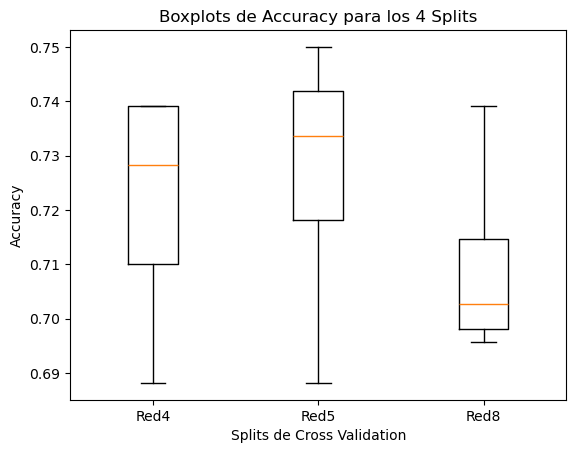

In [55]:
# Crear un boxplot para los cuatro valores de accuracy
plt.boxplot([ac_1.values,ac_2.values,ac_3.values], tick_labels = ['Red4','Red5','Red8'])
plt.title('Boxplots de Accuracy para los 4 Splits')
plt.xlabel('Splits de Cross Validation')
plt.ylabel('Accuracy')
plt.show()

## Otra forma de convertir la variable objetivo nominal a 0/1 si hace falta para algún método
`LabelBinarizer`
```python
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()
y_bin = lb.fit_transform(y).ravel()   # produce 0/1
```


Área bajo la curva ROC (AUC) para la red 4 en test: 0.65


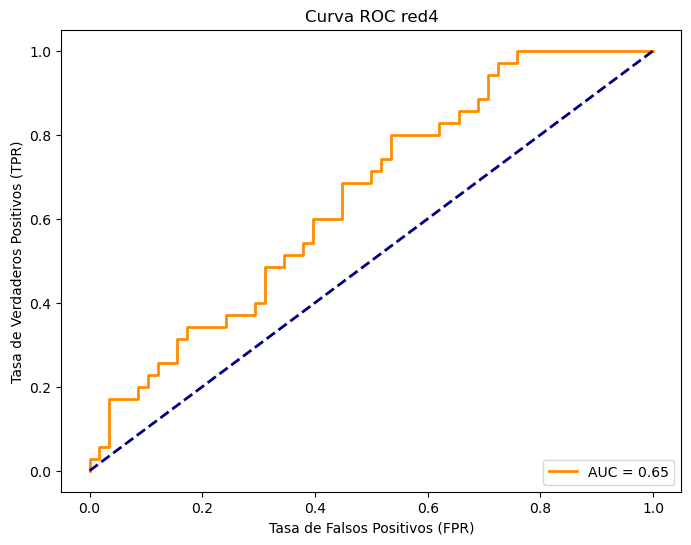

In [60]:
#analizar y reentrenar redes candidatas AUC
from sklearn.preprocessing import LabelBinarizer
X = df[['famhist','tobacco','alcohol']] #en X las variables ya están normalizadas y con dummies
y = df['chd']
lb = LabelBinarizer()
y_bin = lb.fit_transform(y).ravel()   # produce 0/1#para calcular el AUC, y debe ser numérica

X_train, X_test, y_train, y_test = train_test_split(X, y_bin, test_size=0.2, random_state=seed)


red4 = MLPClassifier(**results.iloc[4].params,random_state=seed)
red5 = MLPClassifier(**results.iloc[5].params,random_state=seed)
red8 = MLPClassifier(**results.iloc[8].params,random_state=seed)

# Ajustamos
red4.fit(X_train, y_train)
red5.fit(X_train, y_train)
red8.fit(X_train, y_train)


# Calculamos las predicciones en test, en términos de probabilidad para poder dibujar el AUC
y_pred4 = red4.predict_proba(X_test)[:,1]
y_pred5 = red5.predict_proba(X_test)[:,1]
y_pred8 = red8.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred4)
roc_auc = auc(fpr, tpr)
print(f"\nÁrea bajo la curva ROC (AUC) para la red 4 en test: {roc_auc:.2f}")

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC red4')
plt.legend(loc="lower right")
plt.show()

# Paso final
Una vez que hemos escogido nuestro modelo candidato ganador, después de haber hecho todas las pruebas de CV que garantizan estabilidad y haber expuesto los argumentos que sustentan por qué es mi modelo candidato, tengo que volver a hacer la partición tr/ts, entrenar el modelo replicando exactamente el flujo de trabajo (incluyendo transformaciones y selección de variables), y volver a entrenarlo. Los parámetros obtenidos en entrenamiento serán los que se lleven a la producción. La calidad evaluada para esos parámetros en la parte de test, será la calidad final de mi modelo.

**IMPORTANTE** replicar el proceso de preparación hasta llegar a la arquitectura de la red

In [62]:
# medidas de bondad de ajuste en test: ojo, necesitamos la clasificación continua
X = df[['famhist','tobacco','alcohol']] #en X las variables ya están normalizadas y con dummies
y = df['chd']

# 1. División de dato
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

## 2. Transformación de variables
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
transformador = ColumnTransformer([('OHE',OneHotEncoder(drop='first'),['famhist']), 
                                   ('MinMax',MinMaxScaler(),['tobacco','alcohol'])])
X_train=transformador.fit_transform(X_train)
X_test=transformador.transform(X_test)

# Definimos el modelo
red4 = MLPClassifier(**results.iloc[4].params,random_state=seed)

#Ajustamos
red4.fit(X_train, y_train)


#calculamos las predicciones en test, en términos de probabilidad para poder dibujar el AUC
y_pred4 = red4.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred4)
print("Matriz de Confusión:")
print(conf_matrix)
print("\nMedidas de Desempeño:")
print(classification_report(y_test, y_pred4))

Matriz de Confusión:
[[48 10]
 [26  9]]

Medidas de Desempeño:
              precision    recall  f1-score   support

          No       0.65      0.83      0.73        58
         Yes       0.47      0.26      0.33        35

    accuracy                           0.61        93
   macro avg       0.56      0.54      0.53        93
weighted avg       0.58      0.61      0.58        93



## Interpretación
Estos resultados que acabo de calcular son los que de verdad me hablan de la calidad de los resultados. 
En este caso, la matriz de confusión me dice que tengo más falsos positivos que verdaderos positivos: NO LO ESTOY HACIENDO BIEN!